In [34]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

%matplotlib widget

In [47]:
WIN_AZ = 256
WIN_RG = 128
STRIDE_AZ = 16
STRIDE_RG = 16

In [60]:
fname = 'data/nisar/us/NISAR_L1_PR_RSLC_010_018_A_018_0005_NADV_A_20260110T102944_20260110T102953_X05010_N_P_J_001.h5'
path = 'science/LSAR/RSLC/swaths/frequencyB/VV'

with h5py.File(fname, "r") as f:
    slc = f[path][:]
    zdt = f['science/LSAR/RSLC/swaths/zeroDopplerTime'][()]

amplitude = np.abs(slc)
phase = np.angle(slc)

intensity = np.abs(slc) ** 2

dt_a = zdt[1]-zdt[0]

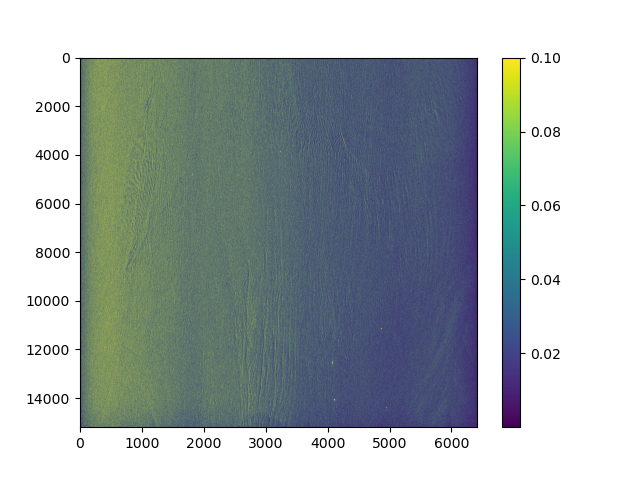

In [38]:
plt.close()
plt.imshow(intensity, vmax=0.1, aspect='auto')
plt.colorbar()
plt.show()

In [46]:
def fft_doppler(
    slc: str,
    dt_a: str,
    win_az: int,
    win_rg: int,
    stride_az: int,
    stride_rg: int,
    smooth_sigma: float | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Estimate Doppler centroids using the FFT weighted-centroid method.

    For each azimuth×range window the azimuth FFT is computed, range pixels
    are averaged (increasing SNR), and the centroid of the power spectrum is
    returned.

    Parameters
    ----------
    slc_path, slc_par_path : str
        Paths to the GAMMA RS SLC and .par files.
    win_az, win_rg : int
        Window size in azimuth and range pixels.
    stride_az, stride_rg : int
        Step size between windows in azimuth and range.
    smooth_sigma : float or None
        Standard deviation (in frequency bins) for Gaussian smoothing applied
        to the power spectrum before centroid estimation. If None (default),
        no smoothing is applied. Stored spectra reflect the smoothed values.

    Returns
    -------
    doppler_img : np.ndarray, shape (n_az*stride_az, n_rg*stride_rg)
        Doppler centroid frequency [Hz] tiled to pixel resolution.
    freqs : np.ndarray, shape (win_az,)
        Frequency axis of the power spectrum [Hz].
    spectrum : np.ndarray of objects, shape (n_az, n_rg)
        Per-window range-averaged power spectrum P [shape (win_az,)].
    """

    n_az = (slc.shape[0] - win_az) // stride_az + 1
    n_rg = (slc.shape[1] - win_rg) // stride_rg + 1

    freqs = np.fft.fftshift(np.fft.fftfreq(win_az, d=dt_a))
    doppler_img = np.zeros((n_az * stride_az, n_rg * stride_rg))
    spectrum = np.empty((n_az, n_rg), dtype=object)

    for j in range(n_az):
        az_0 = j * stride_az
        for i in range(n_rg):
            rg_0 = i * stride_rg

            patch = slc[az_0:az_0 + win_az, rg_0:rg_0 + win_rg]
            S = np.fft.fftshift(np.fft.fft(patch, axis=0), axes=0)
            P = np.sum(np.abs(S) ** 2, axis=1)

            f_dc = np.sum(freqs * P) / np.sum(P)
            spectrum[j, i] = P
            doppler_img[j * stride_az:(j + 1) * stride_az,
                        i * stride_rg:(i + 1) * stride_rg] = f_dc

    return doppler_img, freqs, spectrum

In [61]:
dc_img_fft, freqs, spectrum = fft_doppler(slc, dt_a, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG, smooth_sigma=None)

Text(0, 0.5, 'Power')

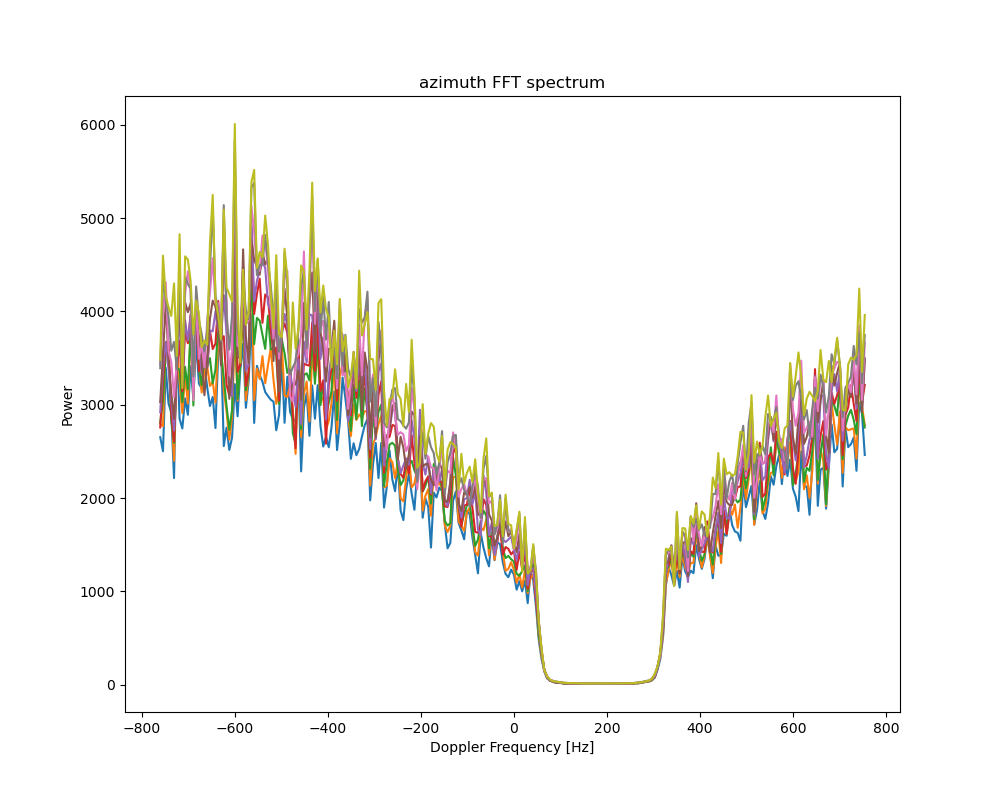

In [67]:
fig,ax = plt.subplots(1,1, figsize=(10,8))

for i in np.arange(1,10):
    ax.plot(freqs, spectrum[1,i])
ax.set_title("azimuth FFT spectrum")
ax.set_xlabel("Doppler Frequency [Hz]")
ax.set_ylabel("Power")

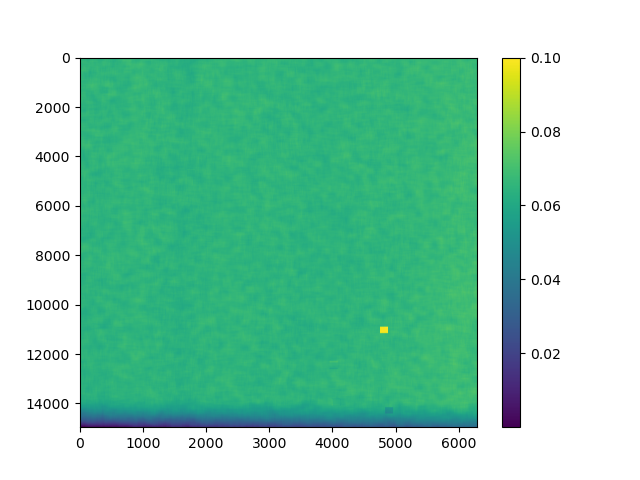

In [64]:
plt.imshow(dc_img_fft, aspect='auto')
plt.show()

In [53]:
fname = 'data/nisar/us/NISAR_L1_PR_RSLC_010_018_A_018_0005_NADV_A_20260110T102944_20260110T102953_X05010_N_P_J_001.h5'
path = 'science/LSAR/RSLC/swaths/frequencyB'

xr.open_dataset(fname, group=path)#['processedCenterFrequency'].values

<xarray.Dataset> Size: 2GB
Dimensions:                        (phony_dim_22: 15200, phony_dim_23: 6410,
                                    phony_dim_24: 2)
Dimensions without coordinates: phony_dim_22, phony_dim_23, phony_dim_24
Data variables: (12/15)
    VH                             (phony_dim_22, phony_dim_23) {'names': ['r', 'i'], 'formats': ['<f4', '<f4'], 'offsets': [0, 4], 'itemsize': 8, 'aligned': True} 779MB ...
    VV                             (phony_dim_22, phony_dim_23) {'names': ['r', 'i'], 'formats': ['<f4', '<f4'], 'offsets': [0, 4], 'itemsize': 8, 'aligned': True} 779MB ...
    acquiredCenterFrequency        float64 8B ...
    acquiredRangeBandwidth         float64 8B ...
    listOfPolarizations            (phony_dim_24) <U2 16B ...
    nominalAcquisitionPRF          float64 8B ...
    ...                             ...
    processedRangeBandwidth        float64 8B ...
    sceneCenterAlongTrackSpacing   float64 8B ...
    sceneCenterGroundRangeSpacing  float64 8B ...
    slantRange                     (phony_dim_23) float64 51kB ...
    slantRangeSpacing              float64 8B ...
    validSamplesSubSwath1          (phony_dim_22, phony_dim_24) uint32 122kB ...